In [16]:
import pywswat.mikeio as mikewave
import mikeio

## Input file

In [6]:
fn_sample = r"D:\STKI\M21WFM\Examples\Ronne\Tri_irregular_3d_refined.mwfm - Result Files\grid2d.dfs2"
ds_2d = mikeio.read(fn_sample)

Plot

<Axes: xlabel='[m]', ylabel='[m]'>

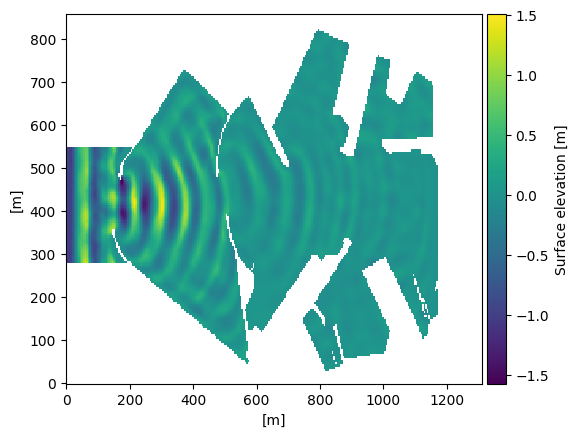

In [7]:
ds_2d["Surface elevation"].isel(time=-1).plot()

## Time/space
Start/end

<Axes: xlabel='[m]', ylabel='[m]'>

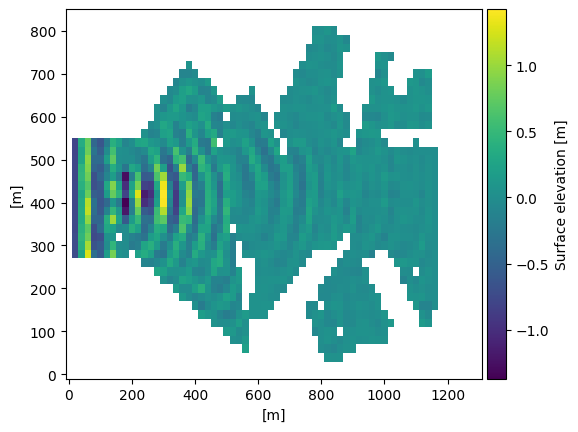

In [ ]:
ds_2d_sub = mikewave.subset_area(
    ds_2d, x=slice(None, None, 20), y=slice(None, None, 20)
)
ds_2d_sub["Surface elevation"].isel(time=-1).plot()

## FFT Parameters

Resolution

In [9]:
fft_size = 128

Data window

In [10]:
window_type = "hann"
overlap = 0.5

Cut-off frequency

In [11]:
f0 = None
f1 = 0.125

In [12]:
ds_2d_sub

<mikeio.Dataset>
dims: (time:1901, y:43, x:66)
time: 1990-01-01 12:03:20 - 1990-01-01 12:35:00 (1901 records)
geometry: Grid2D (ny=43, nx=66)
items:
  0:  Surface elevation <Surface Elevation> (meter)
  1:  Total water depth <Water Depth> (meter)
  2:  Depth averaged U velocity <u velocity component> (meter per sec)
  3:  Depth averaged V velocity <v velocity component> (meter per sec)
  4:  P flux <Flow Flux> (meter pow 3 per sec per meter)
  5:  Q flux <Flow Flux> (meter pow 3 per sec per meter)

## Analysis

In [13]:
itm_se = "Surface elevation"
itm_u = "Depth averaged U velocity"
itm_v = "Depth averaged V velocity"

In [ ]:
ds = mikewave.spectral_params(
    ds_2d_sub,
    elevation=itm_se,
    u=itm_u,
    v=itm_v,
    window=window_type,
    overlap=overlap,
    window_size=fft_size,
)

Computing MEM spectrum at grid locations: 100%|██████████| 2838/2838 [00:17<00:00, 165.49it/s]


<Axes: xlabel='[m]', ylabel='[m]'>

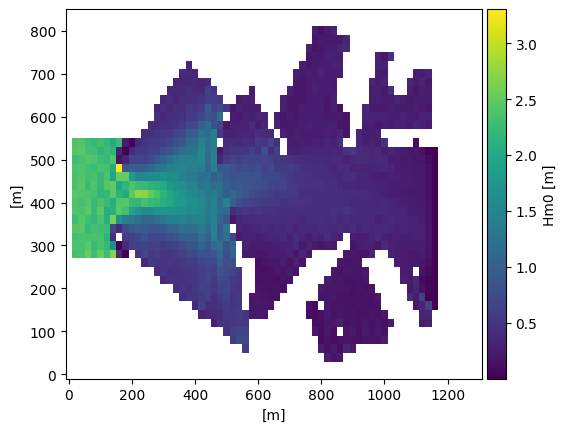

In [15]:
ds["Hm0"].plot()

In [ ]:
ds.to_dfs("out.dfs2")

## Extended example:
short/long waves  - seperated at 0.04 Hz (25s)

In [19]:
freqs = {
    "long": (0, 0.04),
    "short": (0.04, 1),
    "total": (0, 1),
}

ds_lst = {}
for freq_type, (fmin, fmax) in freqs.items():
    ds = mikewave.spectral_params(
        ds_2d_sub,
        elevation=itm_se,
        u=itm_u,
        v=itm_v,
        window=window_type,
        overlap=overlap,
        window_size=fft_size,
        fmin=fmin,
        fmax=fmax,
    )

    ds_lst[freq_type] = ds

Computing MEM spectrum at grid locations: 100%|██████████| 2838/2838 [00:16<00:00, 171.06it/s]


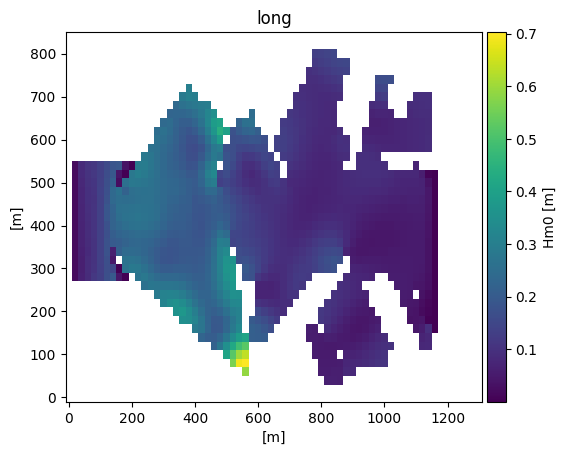

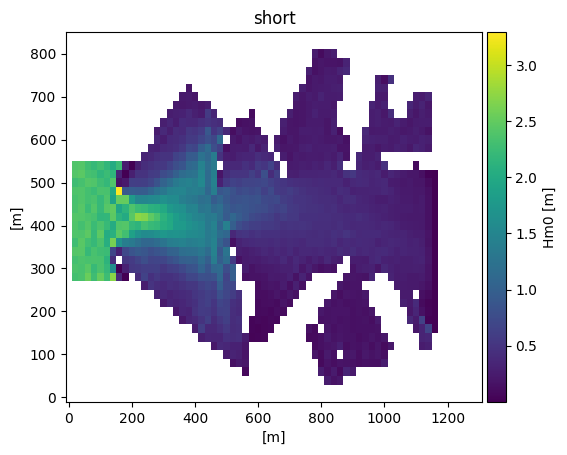

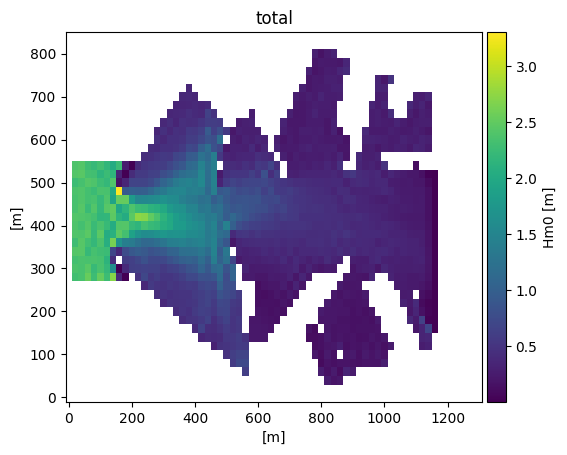

In [22]:
for freq_type, ds in ds_lst.items():
    ax = ds["Hm0"].plot()
    ax.set_title(freq_type)